<a href="https://colab.research.google.com/github/Jaideep3020/HDFC_ALGORITHM/blob/upscaling/cv_repo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Check GPU
!nvidia-smi

Mon Mar 30 13:36:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%%bash
pip install "numpy<2" -q
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 -q
pip install scipy kornia hydra-core pytorch-lightning tqdm seaborn easydict scikit-image wget -q
pip install cython -q
pip install git+https://github.com/lucasb-eyer/pydensecrf.git -q
pip install torchpq -q
pip install matplotlib==3.8.0 -q
pip install --upgrade setuptools pip -q
pip install pytorch-lightning --upgrade -q
echo "ALL DONE"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 118.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 48.5 MB/s eta 0:00:00
ALL DONE


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 require

In [ ]:
import os
os.kill(os.getpid(), 9)

In [1]:
import numpy as np
import torch, torchvision, scipy, kornia, matplotlib, pytorch_lightning

print("✅ numpy:", np.__version__)
print("✅ torch:", torch.__version__)
print("✅ torchvision:", torchvision.__version__)
print("✅ scipy:", scipy.__version__)
print("✅ kornia:", kornia.__version__)
print("✅ matplotlib:", matplotlib.__version__)
print("✅ pytorch_lightning:", pytorch_lightning.__version__)
print("✅ CUDA:", torch.cuda.is_available())
print("✅ GPU:", torch.cuda.get_device_name(0))

✅ numpy: 1.26.4
✅ torch: 2.10.0+cu128
✅ torchvision: 0.25.0+cu128
✅ scipy: 1.16.3
✅ kornia: 0.8.2
✅ matplotlib: 3.8.0
✅ pytorch_lightning: 2.6.1
✅ CUDA: True
✅ GPU: Tesla T4


In [2]:
import os

# Diagnostic: Print current working directory before cloning
print(f"Current working directory before clone: {os.getcwd()}")

if not os.path.exists("/content/EAGLE"):
    !git clone https://github.com/MICV-yonsei/EAGLE.git
print("✅ EAGLE ready")

# Diagnostic: List contents of /content/ to see if EAGLE was cloned there
print(f"Contents of /content/ after clone:")
!ls -F /content/

# Diagnostic: Search for EAGLE directory if not found in /content/
if not os.path.exists("/content/EAGLE"):
    print("EAGLE not found in /content/, searching system...")
    !find / -name EAGLE -type d 2>/dev/null

Current working directory before clone: /content
Cloning into 'EAGLE'...
remote: Enumerating objects: 90, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 90 (delta 25), reused 31 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (90/90), 9.23 MiB | 14.17 MiB/s, done.
Resolving deltas: 100% (25/25), done.
✅ EAGLE ready
Contents of /content/ after clone:
EAGLE/	sample_data/


In [3]:
import os, json
os.makedirs("/root/.config/kaggle", exist_ok=True)

KAGGLE_USERNAME = "navneetbavineni"   # ← replace
KAGGLE_KEY      = "KGAT_e8a57701f90d073c34b31e6f6db88d34"    # ← replace with NEW key

with open("/root/.config/kaggle/kaggle.json", "w") as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)

os.chmod("/root/.config/kaggle/kaggle.json", 0o600)
print("✅ Kaggle authenticated!")

✅ Kaggle authenticated!


In [4]:
import kagglehub
path = kagglehub.dataset_download("awsaf49/coco-2017-dataset")
print("✅ COCO path:", path)
!ls {path}/coco2017/

Using Colab cache for faster access to the 'coco-2017-dataset' dataset.
✅ COCO path: /kaggle/input/coco-2017-dataset
annotations  test2017  train2017  val2017


In [5]:
import os
os.makedirs("/content/EAGLE/src_EAGLE/models", exist_ok=True)

!wget -q --show-progress \
    https://dl.fbaipublicfiles.com/dino/dino_deitsmall8_pretrain/dino_deitsmall8_pretrain.pth \
    -O /content/EAGLE/src_EAGLE/models/dino_deitsmall8_pretrain.pth

print("✅ DINO downloaded!")

/content/EAGLE/src_ 100%[===================>]  82.71M   170MB/s    in 0.5s    
✅ DINO downloaded!


In [6]:
import os

COCO_DIR = f"{path}/coco2017"
BASE = "/content/data/cocostuff"

for d in ["imgs/train", "imgs/val", "labels/train", "labels/val", "annotations"]:
    os.makedirs(f"{BASE}/{d}", exist_ok=True)

# Symlink images
for split, src_folder in [("train", "train2017"), ("val", "val2017")]:
    for img in os.listdir(f"{COCO_DIR}/{src_folder}"):
        src = f"{COCO_DIR}/{src_folder}/{img}"
        dst = f"{BASE}/imgs/{split}/{img}"
        if not os.path.exists(dst):
            os.symlink(src, dst)

# Symlink annotations
for f in os.listdir(f"{COCO_DIR}/annotations"):
    src = f"{COCO_DIR}/annotations/{f}"
    dst = f"{BASE}/annotations/{f}"
    if not os.path.exists(dst):
        os.symlink(src, dst)

print("✅ Images & annotations symlinked!")
print("train:", len(os.listdir(f"{BASE}/imgs/train")))
print("val:  ", len(os.listdir(f"{BASE}/imgs/val")))

✅ Images & annotations symlinked!
train: 118287
val:   5000


In [7]:
!wget -q --show-progress \
    http://calvin.inf.ed.ac.uk/wp-content/uploads/data/cocostuffdataset/stuffthingmaps_trainval2017.zip \
    -O /content/stuffthingmaps.zip

!unzip -q /content/stuffthingmaps.zip -d /content/stuffthingmaps/

# Symlink labels
import os
BASE = "/content/data/cocostuff"
for split in ["train", "val"]:
    for f in os.listdir(f"/content/stuffthingmaps/{split}2017"):
        src = f"/content/stuffthingmaps/{split}2017/{f}"
        dst = f"{BASE}/labels/{split}/{f}"
        if not os.path.exists(dst):
            os.symlink(src, dst)

print("✅ Labels symlinked!")
print("train labels:", len(os.listdir(f"{BASE}/labels/train")))
print("val labels:  ", len(os.listdir(f"{BASE}/labels/val")))

/content/stuffthing 100%[===================>] 628.48M  16.1MB/s    in 54s     
✅ Labels symlinked!
train labels: 118287
val labels:   5000


In [8]:
import re, os

# --- Diagnostics: List directory contents to verify structure ---
# The EAGLE directory has been confirmed to exist in /content/ by AafBIY3rWXlj execution.
# Removing diagnostic print statements as they are no longer needed.

src = "/content/EAGLE/src_EAGLE"

# 1. Rename .yml → .yaml
for fn in os.listdir(f"{src}/configs"):
    if fn.endswith(".yml"):
        os.rename(f"{src}/configs/{fn}", f"{src}/configs/{fn[:-4]}.yaml")
        print(f"✅ Renamed {fn}")

# 2. Fix all .py files
replacements = [
    ("from torch._six import string_classes",
     "string_classes = (str,)"),
    ("from pytorch_lightning.utilities.seed import seed_everything",
     "from pytorch_lightning import seed_everything"),
    ("from torchvision.transforms.functional import five_crop, _get_image_size, crop",
     "from torchvision.transforms.functional import five_crop, get_image_size, crop"),
    ("image_width, image_height = _get_image_size(img)",
     "image_width, image_height = get_image_size(img)"),
]

for fn in os.listdir(src):
    if not fn.endswith(".py"):
        continue
    fp = f"{src}/{fn}"
    t = open(fp).read()
    changed = False
    for old, new in replacements:
        if old in t:
            t = t.replace(old, new)
            changed = True
            print(f"✅ {fn}: patched '{old[:50]}'")
    new_t = re.sub(
        r'@hydra\.main\(config_path="configs",\s*config_name="([^"]+?)(?:\.yml|\.yaml)?"\)',
        r'@hydra.main(config_path="configs", config_name="\1", version_base="1.1")',
        t
    )
    if new_t != t:
        t = new_t
        changed = True
        print(f"✅ {fn}: fixed hydra decorator")
    if changed:
        open(fp, "w").write(t)

# 3. Fix crop_datasets.py
f = "/content/EAGLE/src_EAGLE/crop_datasets.py"
t = open(f).read()

# Switch dataset to cocostuff27
t = t.replace(
    'dataset_names = ["cityscapes"]',
    'dataset_names = ["cocostuff27"]'
)

# Fix ContrastiveSegDataset call
old_call = re.search(r'self\\.dataset = ContrastiveSegDataset\\(.*\\?)', t, re.DOTALL)
if old_call:
    t = t.replace(old_call.group(), """self.dataset = ContrastiveSegDataset(
            cfg.pytorch_data_dir,
            dataset_name,
            crop_type,
            img_set,
            T.ToTensor(),
            ToTargetTensor(),
            # cfg=cfg, # REMOVED THIS LINE
            aug_geometric_transform=None,
            aug_photometric_transform=None,
            mask=False,
            extra_transform=cropper
        )""")
    print("✅ crop_datasets.py: ContrastiveSegDataset call fixed")
open(f, "w").write(t)

# 4. Update train config
cfg_file = f"{src}/configs/train_config_cocostuff.yaml"
cfg_text = open(cfg_file).read()
cfg_text = re.sub(r"pytorch_data_dir:.*", "pytorch_data_dir: '/content/data'", cfg_text)
cfg_text = re.sub(r"azureml_logging:.*", "azureml_logging: False", cfg_text)
cfg_text = re.sub(r"num_workers:.*", "num_workers: 2", cfg_text)
cfg_text = re.sub(r"batch_size:.*", "batch_size: 8", cfg_text)
if "num_neighbors" not in cfg_text:
    cfg_text += "\nnum_neighbors: 7"
open(cfg_file, "w").write(cfg_text)
print("✅ Config updated!")

print("\n🎉 ALL PATCHES DONE!")

✅ Renamed plot_config.yml
✅ Renamed demo_config.yml
✅ Renamed eval_config.yml
✅ Renamed train_config_cityscapes.yml
✅ Renamed train_config_cocostuff.yml
✅ eval_segmentation.py: fixed hydra decorator
✅ train_segmentation_eigen.py: patched 'from pytorch_lightning.utilities.seed import seed_'
✅ train_segmentation_eigen.py: fixed hydra decorator
✅ download_datasets.py: fixed hydra decorator
✅ crop_datasets.py: patched 'from pytorch_lightning.utilities.seed import seed_'
✅ crop_datasets.py: patched 'from torchvision.transforms.functional import five'
✅ crop_datasets.py: patched 'image_width, image_height = _get_image_size(img)'
✅ crop_datasets.py: fixed hydra decorator
✅ utils.py: patched 'from torch._six import string_classes'
✅ Config updated!

🎉 ALL PATCHES DONE!


In [9]:
new_content = '''from modules import *
import os
from data import ContrastiveSegDataset
import hydra
import torch
from omegaconf import DictConfig, OmegaConf
from pytorch_lightning import seed_everything
from torch.utils.data import DataLoader
from torchvision.transforms.functional import five_crop, get_image_size, crop
from tqdm import tqdm
from torch.utils.data import Dataset


def _random_crops(img, size, seed, n):
    if isinstance(size, int):
        size = (int(size), int(size))
    elif isinstance(size, (tuple, list)) and len(size) == 1:
        size = (size[0], size[0])
    if len(size) != 2:
        raise ValueError("Please provide only two dimensions (h, w) for size.")
    image_width, image_height = get_image_size(img)
    crop_height, crop_width = size
    if crop_width > image_width or crop_height > image_height:
        msg = "Requested crop size {} is bigger than input size {}"
        raise ValueError(msg.format(size, (image_height, image_width)))
    images = []
    for i in range(n):
        seed1 = hash((seed, i, 0))
        seed2 = hash((seed, i, 1))
        crop_height, crop_width = int(crop_height), int(crop_width)
        top = seed1 % (image_height - crop_height)
        left = seed2 % (image_width - crop_width)
        images.append(crop(img, top, left, crop_height, crop_width))
    return images


class RandomCropComputer(Dataset):

    def _get_size(self, img):
        if len(img.shape) == 3:
            return [int(img.shape[1] * self.crop_ratio), int(img.shape[2] * self.crop_ratio)]
        elif len(img.shape) == 2:
            return [int(img.shape[0] * self.crop_ratio), int(img.shape[1] * self.crop_ratio)]
        else:
            raise ValueError("Bad image shape {}".format(img.shape))

    def random_crops(self, i, img):
        return _random_crops(img, self._get_size(img), i, 5)

    def five_crops(self, i, img):
        return five_crop(img, self._get_size(img))

    def __init__(self, cfg, dataset_name, img_set, crop_type, crop_ratio):
        self.pytorch_data_dir = cfg.pytorch_data_dir
        self.crop_ratio = crop_ratio
        self.save_dir = join(
            cfg.pytorch_data_dir, "cropped", "{}_{}_crop_{}".format(dataset_name, crop_type, crop_ratio))
        self.img_set = img_set
        self.dataset_name = dataset_name
        self.cfg = cfg

        self.img_dir = join(self.save_dir, "img", img_set)
        self.label_dir = join(self.save_dir, "label", img_set)
        os.makedirs(self.img_dir, exist_ok=True)
        os.makedirs(self.label_dir, exist_ok=True)

        if crop_type == "random":
            cropper = lambda i, x: self.random_crops(i, x)
        elif crop_type == "five":
            cropper = lambda i, x: self.five_crops(i, x)
        else:
            raise ValueError("Unknown crop type {}".format(crop_type))

        self.dataset = ContrastiveSegDataset(
            cfg.pytorch_data_dir,
            dataset_name,
            None,
            img_set,
            T.ToTensor(),
            ToTargetTensor(),
            cfg=cfg,
            aug_geometric_transform=None,
            aug_photometric_transform=None,
            mask=False,
            extra_transform=cropper
        )

    def __getitem__(self, item):
        batch = self.dataset[item]
        imgs = batch["img"]
        labels = batch["label"]
        for crop_num, (img, label) in enumerate(zip(imgs, labels)):
            img_num = item * 5 + crop_num
            img_arr = img.mul(255).add_(0.5).clamp_(0, 255).permute(1, 2, 0).to("cpu", torch.uint8).numpy()
            label_arr = (label + 1).unsqueeze(0).permute(1, 2, 0).to("cpu", torch.uint8).numpy().squeeze(-1)
            Image.fromarray(img_arr).save(join(self.img_dir, "{}.jpg".format(img_num)), "JPEG")
            Image.fromarray(label_arr).save(join(self.label_dir, "{}.png".format(img_num)), "PNG")
        return True

    def __len__(self):
        return len(self.dataset)


@hydra.main(config_path="configs", config_name="train_config_cocostuff", version_base="1.1")
def my_app(cfg: DictConfig) -> None:
    print(OmegaConf.to_yaml(cfg))
    seed_everything(seed=0, workers=True)

    dataset_names = ["cocostuff27"]
    img_sets = ["train", "val"]
    crop_types = ["five"]
    crop_ratios = [.5]

    for crop_ratio in crop_ratios:
        for crop_type in crop_types:
            for dataset_name in dataset_names:
                for img_set in img_sets:
                    dataset = RandomCropComputer(cfg, dataset_name, img_set, crop_type, crop_ratio)
                    loader = DataLoader(dataset, 1, shuffle=False, num_workers=cfg.num_workers, collate_fn=lambda l: l)
                    for _ in tqdm(loader):
                        pass


if __name__ == "__main__":
    prep_args()
    my_app()
'''

with open("/content/EAGLE/src_EAGLE/crop_datasets.py", "w") as f:
    f.write(new_content)

print("✅ crop_datasets.py rewritten!")
%cd /content/EAGLE/src_EAGLE

✅ crop_datasets.py rewritten!
/content/EAGLE/src_EAGLE


In [10]:
import os

COCO_DIR = "/content/data/cocostuff"

os.makedirs(f"{COCO_DIR}/curated/train2017", exist_ok=True)
os.makedirs(f"{COCO_DIR}/curated/val2017", exist_ok=True)

train_imgs = sorted([f.replace(".jpg", "") for f in os.listdir(f"{COCO_DIR}/imgs/train") if f.endswith(".jpg")])
val_imgs   = sorted([f.replace(".jpg", "") for f in os.listdir(f"{COCO_DIR}/imgs/val")   if f.endswith(".jpg")])

for fname in ["Coco164kFull_Stuff_Coarse.txt", "Coco164kFull_Stuff_Coarse_7.txt"]:
    with open(f"{COCO_DIR}/curated/train2017/{fname}", "w") as f:
        f.write("\n".join(train_imgs))
    with open(f"{COCO_DIR}/curated/val2017/{fname}", "w") as f:
        f.write("\n".join(val_imgs))

print("✅ Curated lists created!")
print("Train images listed:", len(train_imgs))
print("Val images listed:  ", len(val_imgs))
!ls /content/data/cocostuff/curated/train2017/
!ls /content/data/cocostuff/curated/val2017/

✅ Curated lists created!
Train images listed: 118287
Val images listed:   5000
Coco164kFull_Stuff_Coarse_7.txt  Coco164kFull_Stuff_Coarse.txt
Coco164kFull_Stuff_Coarse_7.txt  Coco164kFull_Stuff_Coarse.txt


In [11]:
import os

os.makedirs("/content/data/cocostuff/images", exist_ok=True)

# EAGLE expects 'images/train2017' and 'images/val2017'
if not os.path.exists("/content/data/cocostuff/images/train2017"):
    os.symlink("/content/data/cocostuff/imgs/train",
               "/content/data/cocostuff/images/train2017")

if not os.path.exists("/content/data/cocostuff/images/val2017"):
    os.symlink("/content/data/cocostuff/imgs/val",
               "/content/data/cocostuff/images/val2017")

print("✅ Symlinks created!")
print("train:", len(os.listdir("/content/data/cocostuff/images/train2017")))
print("val:  ", len(os.listdir("/content/data/cocostuff/images/val2017")))

✅ Symlinks created!
train: 118287
val:   5000


In [12]:
import os

# EAGLE expects annotations/train2017 and annotations/val2017 for PNG masks
if not os.path.exists("/content/data/cocostuff/annotations/train2017"):
    os.symlink("/content/data/cocostuff/labels/train",
               "/content/data/cocostuff/annotations/train2017")

if not os.path.exists("/content/data/cocostuff/annotations/val2017"):
    os.symlink("/content/data/cocostuff/labels/val",
               "/content/data/cocostuff/annotations/val2017")

print("✅ Annotation symlinks created!")
print("train labels:", len(os.listdir("/content/data/cocostuff/annotations/train2017")))
print("val labels:  ", len(os.listdir("/content/data/cocostuff/annotations/val2017")))

✅ Annotation symlinks created!
train labels: 118287
val labels:   5000


In [13]:
# %cd /content/EAGLE/src_EAGLE
# !python crop_datasets.py

In [14]:
!pip install gdown -q
print("✅ gdown ready!")

✅ gdown ready!


In [15]:
import os
os.makedirs("/content/EAGLE/src_EAGLE/checkpoints", exist_ok=True)

!gdown "https://drive.google.com/uc?id=1fRZB_Tx2cZn5XayY0MiC9gv6D9kML7lh" \
    -O /content/EAGLE/src_EAGLE/checkpoints/eagle_coco.ckpt

print("✅ Checkpoint downloaded!")
!ls -lh /content/EAGLE/src_EAGLE/checkpoints/

Downloading...
From (original): https://drive.google.com/uc?id=1fRZB_Tx2cZn5XayY0MiC9gv6D9kML7lh
From (redirected): https://drive.google.com/uc?id=1fRZB_Tx2cZn5XayY0MiC9gv6D9kML7lh&confirm=t&uuid=096960e6-b2ea-4a5a-abfd-2376e7fbcf69
To: /content/EAGLE/src_EAGLE/checkpoints/eagle_coco.ckpt
100% 123M/123M [00:01<00:00, 97.4MB/s]
✅ Checkpoint downloaded!
total 118M
-rw-r--r-- 1 root root 118M May  9  2024 eagle_coco.ckpt


In [16]:
import torch

ckpt = torch.load(
    "/content/EAGLE/src_EAGLE/checkpoints/eagle_coco.ckpt",
    map_location="cpu",
    weights_only=False
)
print("✅ Checkpoint loaded!")
print("Keys:", list(ckpt.keys()))

✅ Checkpoint loaded!
Keys: ['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'callbacks', 'optimizer_states', 'lr_schedulers', 'hparams_name', 'hyper_parameters']


In [17]:
import re

eval_config = "/content/EAGLE/src_EAGLE/configs/eval_config.yaml"

# Read current config
with open(eval_config, "r") as f:
    content = f.read()

print("Current eval config:")
print(content)

Current eval config:
output_root: '../'
pytorch_data_dir: 'pytorch_data_dir'
experiment_name: "cocostuff27"
res: 320
batch_size: 8
num_workers: 8
run_picie: False
run_crf: True
run_prediction: True
dark_mode: True
use_ddp: False

dino_patch_size: 8
dino_feat_type: "feat"
projection_type: "nonlinear"
model_type: "vit_small"
pretrained_weights: ~
dataset_name: "cocostuff27"

model_paths:
 - '../checkpoints/EAGLE_COCO_ViTS8.ckpt'
#  - '../checkpoints/EAGLE_Cityscapes_ViTB8.ckpt'

hydra:
  run:
    dir: "."
  output_subdir: ~


In [18]:
eval_config_content = """
pytorch_data_dir: '/content/data'
output_root: '/content/EAGLE'
experiment_name: 'cocostuff_EAGLE'
log_dir: 'cocostuff27'
dataset_name: 'cocostuff27'

model_paths:
  - '/content/EAGLE/src_EAGLE/checkpoints/eagle_coco.ckpt'

azureml_logging: False

num_workers: 2
batch_size: 8
res: 224
loader_crop_type: 'center'
crop_type: five
crop_ratio: 0.5

model_type: 'vit_small'
arch: 'dino'
dino_feat_type: 'KK'
projection_type: 'nonlinear'
dino_patch_size: 8
dim: 512

use_head: True
num_neighbors: 7
extra_clusters: 5

hydra:
  run:
    dir: '.'
  output_subdir: ~
"""

with open(eval_config, "w") as f:
    f.write(eval_config_content)

print("✅ Eval config written!")

✅ Eval config written!


In [19]:
!pip install kmeans-pytorch -q
print("✅ kmeans_pytorch installed!")

✅ kmeans_pytorch installed!


In [20]:
%cd /content/EAGLE/src_EAGLE
!python eval_segmentation.py

/content/EAGLE/src_EAGLE
2026-03-30 13:40:42.837165: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774878042.858118    8586 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774878042.865497    8586 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774878042.885127    8586 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774878042.885177    8586 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774878042.885182    8586 computation_placer.cc:17

In [21]:
# Patch the checkpoint loading in eval_segmentation.py
import re

fp = "/content/EAGLE/src_EAGLE/eval_segmentation.py"
t = open(fp).read()
print("Before patch:")
print(t[t.find("load_from_checkpoint"):t.find("load_from_checkpoint")+200])

Before patch:
load_from_checkpoint(model_path)
        loader_crop = "center"

        test_dataset = ContrastiveSegDataset(
            pytorch_data_dir=pytorch_data_dir,
            dataset_name=model.cfg.dataset


In [26]:
# Clean patch - directly fix cloud_io.py in lightning_fabric
fp = "/usr/local/lib/python3.12/dist-packages/lightning_fabric/utilities/cloud_io.py"
t = open(fp).read()
print("Current load call:")
# Find the torch.load line
for i, line in enumerate(t.split("\n")):
    if "torch.load" in line:
        print(f"Line {i}: {line}")

Current load call:
Line 52:         return torch.load(
Line 72:         return torch.load(


In [27]:
fp = "/usr/local/lib/python3.12/dist-packages/lightning_fabric/utilities/cloud_io.py"
t = open(fp).read()

# Replace weights_only=weights_only with weights_only=False
if "weights_only=weights_only" in t:
    t = t.replace("weights_only=weights_only", "weights_only=False")
    open(fp, "w").write(t)
    print("✅ Patched: weights_only=weights_only → weights_only=False")
elif "weights_only" in t:
    print("Current weights_only lines:")
    for i, line in enumerate(t.split("\n")):
        if "weights_only" in line:
            print(f"  Line {i}: {repr(line)}")
else:
    print("No weights_only found — printing torch.load context:")
    for i, line in enumerate(t.split("\n")):
        if "torch.load" in line:
            print(f"  Line {i}: {repr(line)}")

Current weights_only lines:
  Line 36: '    weights_only: Optional[bool] = None,'
  Line 43: '        weights_only: If ``True``, restricts loading to ``state_dicts`` of plain ``torch.Tensor`` and other primitive'
  Line 45: '            ``weights_only=False``. If loading checkpoint from an untrusted source, we recommend using'
  Line 46: '            ``weights_only=True``. For more information, please refer to the'
  Line 55: '            weights_only=False,'
  Line 58: '        if weights_only is None:'
  Line 59: '            weights_only = False'
  Line 61: '                f"Defaulting to `weights_only=False` for remote checkpoint: {path_or_url}."'
  Line 62: '                f" If loading a checkpoint from an untrustted source, we recommend using `weights_only=True`."'
  Line 68: '            weights_only=False,'
  Line 75: '            weights_only=False,'


In [28]:
fp = "/content/EAGLE/src_EAGLE/eval_segmentation.py"
t = open(fp).read()

# Remove the bad patch block we added earlier
bad_patch = """
import torch
from pytorch_lightning.core.saving import _load_from_checkpoint
import pytorch_lightning.utilities.cloud_io as cloud_io

_original_load = torch.load

def _patched_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return _original_load(*args, **kwargs)

torch.load = _patched_load
"""

if bad_patch in t:
    t = t.replace(bad_patch, "\n")
    open(fp, "w").write(t)
    print("✅ Bad patch removed from eval_segmentation.py")
else:
    print("ℹ️ Bad patch not found — checking manually:")
    for i, line in enumerate(t.split("\n")):
        if "patched_load" in line or "cloud_io" in line:
            print(f"  Line {i}: {line}")

✅ Bad patch removed from eval_segmentation.py


In [30]:
eval_config = "/content/EAGLE/src_EAGLE/configs/eval_config.yaml"

eval_config_content = """
pytorch_data_dir: '/content/data'
output_root: '/content/EAGLE'
experiment_name: 'cocostuff_EAGLE'
log_dir: 'cocostuff27'
dataset_name: 'cocostuff27'

model_paths:
  - '/content/EAGLE/src_EAGLE/checkpoints/eagle_coco.ckpt'

azureml_logging: False

num_workers: 2
batch_size: 8
res: 224
loader_crop_type: 'center'
crop_type: five
crop_ratio: 0.5

model_type: 'vit_small'
arch: 'dino'
dino_feat_type: 'KK'
projection_type: 'nonlinear'
dino_patch_size: 8
dim: 512

use_head: True
num_neighbors: 7
extra_clusters: 5
use_ddp: False
"""

with open(eval_config, "w") as f:
    f.write(eval_config_content)

print("✅ Eval config updated with use_ddp!")

✅ Eval config updated with use_ddp!


In [32]:
eval_config = "/content/EAGLE/src_EAGLE/configs/eval_config.yaml"

eval_config_content = """
pytorch_data_dir: '/content/data'
output_root: '/content/EAGLE'
experiment_name: 'cocostuff_EAGLE'
log_dir: 'cocostuff27'
dataset_name: 'cocostuff27'

model_paths:
  - '/content/EAGLE/src_EAGLE/checkpoints/eagle_coco.ckpt'

azureml_logging: False

num_workers: 2
batch_size: 8
res: 224
loader_crop_type: 'center'
crop_type: five
crop_ratio: 0.5

model_type: 'vit_small'
arch: 'dino'
dino_feat_type: 'KK'
projection_type: 'nonlinear'
dino_patch_size: 8
dim: 512

use_head: True
num_neighbors: 7
extra_clusters: 5
use_ddp: False
run_crf: False
"""

with open(eval_config, "w") as f:
    f.write(eval_config_content)

print("✅ Config updated with run_crf!")

✅ Config updated with run_crf!


In [57]:
fp = "/content/EAGLE/src_EAGLE/eval_segmentation.py"
t = open(fp).read()

# 1. Add dice computation function after imports
dice_func = '''
def compute_dice_from_preds(all_preds, all_labels):
    max_label = 0
    max_pred = 0

    # Find max indices dynamically
    for pred, label in zip(all_preds, all_labels):
        max_label = max(max_label, int(label.max()))
        max_pred  = max(max_pred,  int(pred.max()))

    num_classes = max(max_label, max_pred) + 1

    confusion = np.zeros((num_classes, num_classes), dtype=np.int64)

    for pred, label in zip(all_preds, all_labels):
        p = pred.cpu().numpy().flatten()
        l = label.cpu().numpy().flatten()

        valid = (l >= 0)
        np.add.at(confusion, (l[valid], p[valid]), 1)

    tp = np.diag(confusion)
    fp = confusion.sum(axis=0) - tp
    fn = confusion.sum(axis=1) - tp

    dice = (2 * tp) / (2 * tp + fp + fn + 1e-10)

    present = (tp + fn) > 0
    return np.nanmean(dice[present]) * 100

'''

t = t.replace(
    "def batch_list(iterable, n=1):",
    dice_func + "def batch_list(iterable, n=1):"
)

# 2. Add storage lists inside the loop — after saved_data = defaultdict(list)
t = t.replace(
    "saved_data = defaultdict(list)",
    "saved_data = defaultdict(list)\n        all_linear_preds, all_cluster_preds, all_labels_list = [], [], []"
)

# 3. Store preds each batch — after model.test_cluster_metrics.update
t = t.replace(
    "                    model.test_linear_metrics.update(linear_preds, label)\n                    model.test_cluster_metrics.update(cluster_preds, label)",
    """                    model.test_linear_metrics.update(linear_preds, label)
                    model.test_cluster_metrics.update(cluster_preds, label)
                    all_linear_preds.append(linear_preds)
                    all_cluster_preds.append(cluster_preds)
                    all_labels_list.append(label)"""
)

# 4. Print dice after tb_metrics print
t = t.replace(
    "        print(tb_metrics)",
    """        print(tb_metrics)

        # Compute and print Dice scores
        linear_dice  = compute_dice_from_preds(all_linear_preds,  all_labels_list)
        cluster_dice = compute_dice_from_preds(all_cluster_preds, all_labels_list)
        print(f\"\\n{'='*50}\")
        print(f\"  Linear  Mean Dice : {linear_dice:.4f}%\")
        print(f\"  Cluster Mean Dice : {cluster_dice:.4f}%\")
        print(f\"{'='*50}\")"""
)

open(fp, "w").write(t)
print("✅ eval_segmentation.py patched with Dice!")

✅ eval_segmentation.py patched with Dice!


In [58]:
with open("/content/EAGLE/src_EAGLE/eval_segmentation.py", "r") as f:
    content = f.read()

# Print just the dice-related sections
for keyword in ["compute_dice_from_preds", "all_linear_preds", "Linear  Mean Dice"]:
    idx = content.find(keyword)
    if idx != -1:
        print(f"✅ Found '{keyword}' at position {idx}")
    else:
        print(f"❌ MISSING: '{keyword}'")

✅ Found 'compute_dice_from_preds' at position 1697
✅ Found 'all_linear_preds' at position 4739
✅ Found 'Linear  Mean Dice' at position 7084


In [59]:
%cd /content/EAGLE/src_EAGLE
!python eval_segmentation.py

/content/EAGLE/src_EAGLE
2026-03-30 14:38:13.318793: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774881493.339482   23656 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774881493.346364   23656 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774881493.364876   23656 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774881493.364925   23656 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774881493.364931   23656 computation_placer.cc:17

In [36]:
# Patch torch.load globally for this session
import torch
from omegaconf import DictConfig, ListConfig

# Allow omegaconf types
torch.serialization.add_safe_globals([DictConfig, ListConfig])

# Monkey-patch torch.load to always use weights_only=False
_original_torch_load = torch.load

def _patched_torch_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return _original_torch_load(*args, **kwargs)

torch.load = _patched_torch_load
print("✅ torch.load patched!")

✅ torch.load patched!


In [37]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

# Load a few val images and run inference
%cd /content/EAGLE/src_EAGLE

import sys
sys.path.insert(0, '/content/EAGLE/src_EAGLE')

from train_segmentation_eigen import LitUnsupervisedSegmenter
import torchvision.transforms as T

# Load model
model = LitUnsupervisedSegmenter.load_from_checkpoint(
    "/content/EAGLE/src_EAGLE/checkpoints/eagle_coco.ckpt"
)
model.eval()
model.cuda()
print("✅ Model loaded!")

INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.5.0 to v2.6.1. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint checkpoints/eagle_coco.ckpt`


/content/EAGLE/src_EAGLE
Since no pretrained weights have been provided, we load the reference pretrained DINO weights.
✅ Model loaded!


In [45]:
# Inspect cluster_probe output
with torch.no_grad():
    out = model.net(torch.randn(1, 3, 224, 224).cuda())
    feats = out[2]
    cp_out = model.cluster_probe(feats, 2, log_probs=False)
    print("cluster_probe output type:", type(cp_out))
    print("cluster_probe output length:", len(cp_out))
    for i, o in enumerate(cp_out):
        if hasattr(o, 'shape'):
            print(f"  cp_out[{i}] shape:", o.shape)
        else:
            print(f"  cp_out[{i}] type:", type(o))

    lp_out = model.linear_probe(feats)
    print("\nlinear_probe output type:", type(lp_out))
    if isinstance(lp_out, tuple):
        for i, o in enumerate(lp_out):
            if hasattr(o, 'shape'):
                print(f"  lp_out[{i}] shape:", o.shape)
    else:
        print("linear_probe output shape:", lp_out.shape)

cluster_probe output type: <class 'tuple'>
cluster_probe output length: 2
  cp_out[0] shape: torch.Size([])
  cp_out[1] shape: torch.Size([1, 32, 28, 28])

linear_probe output type: <class 'torch.Tensor'>
linear_probe output shape: torch.Size([1, 27, 28, 28])



Processing: 000000407083.jpg


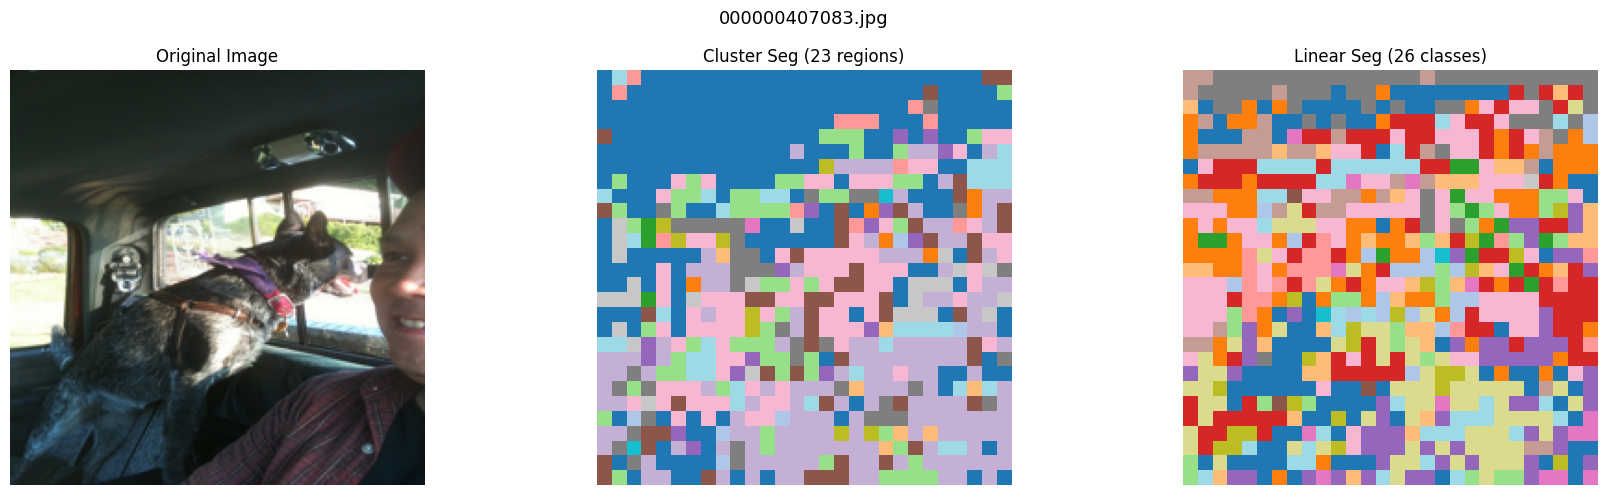

✅ Saved to /content/eagle_000000407083.png

Processing: 000000125257.jpg


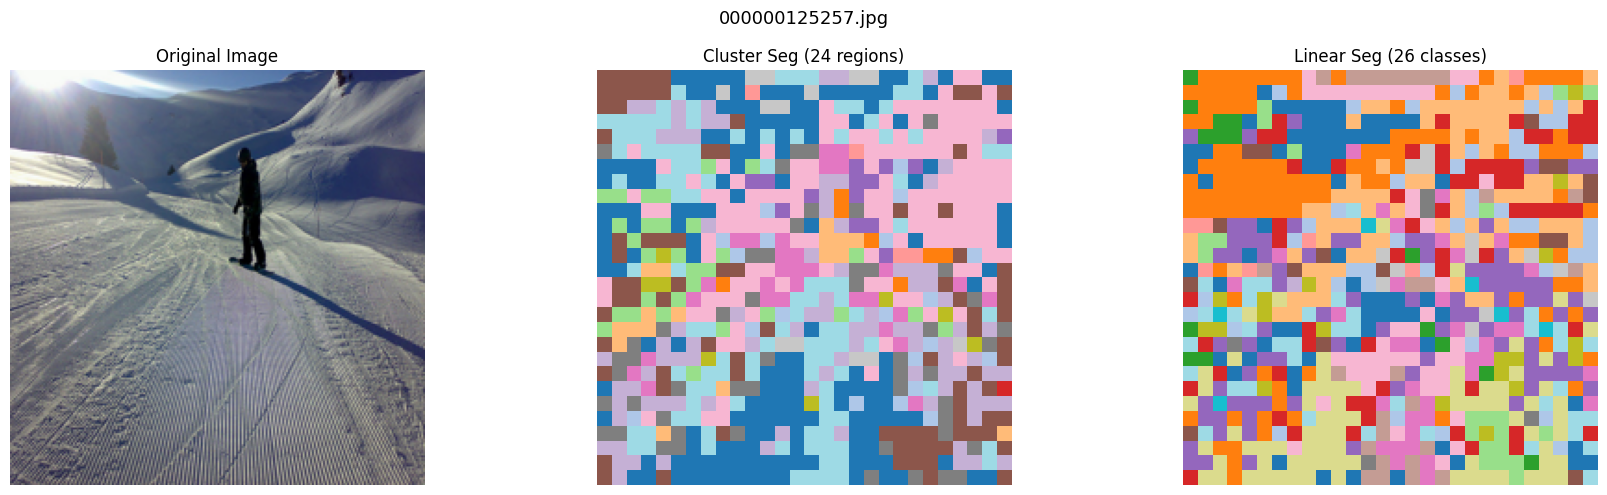

✅ Saved to /content/eagle_000000125257.png

Processing: 000000361621.jpg


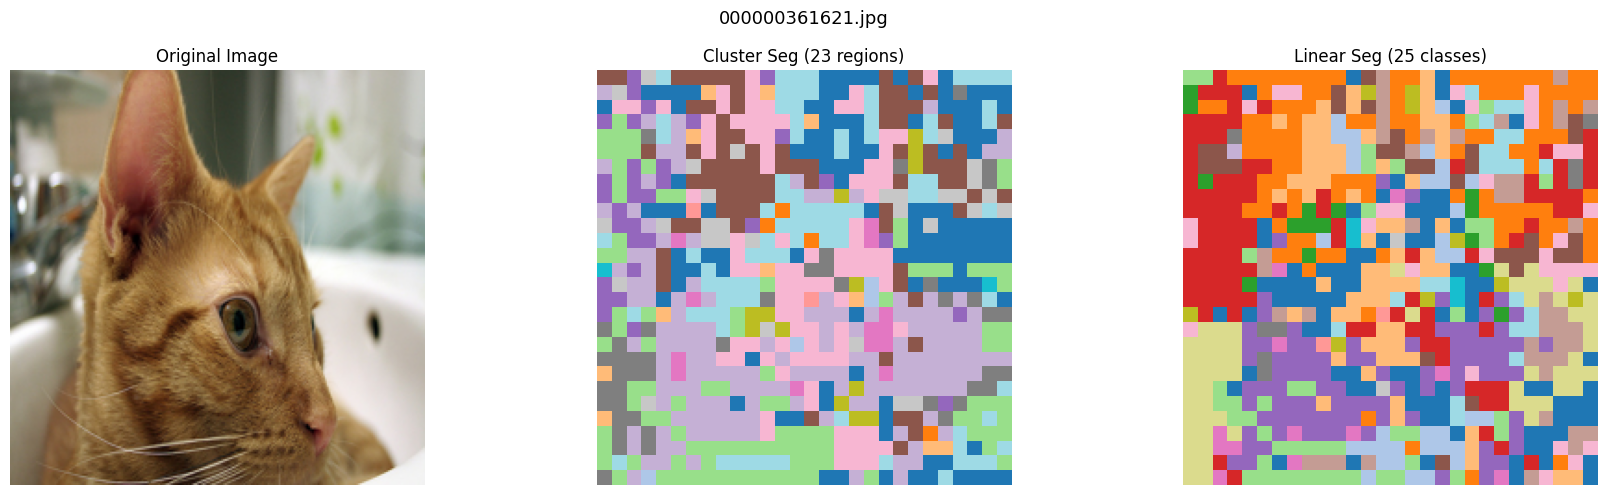

✅ Saved to /content/eagle_000000361621.png


In [46]:
def segment_image(img_path, model, res=224):
    transform = T.Compose([
        T.Resize((res, res)),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406],
                    [0.229, 0.224, 0.225])
    ])

    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).cuda()

    with torch.no_grad():
        out = model.net(img_tensor)
        feats = out[2]  # [1, 512, 28, 28]

        # cluster_probe returns (loss, logits) → take [1]
        _, cluster_logits = model.cluster_probe(feats, 2, log_probs=False)
        cluster_seg = cluster_logits.argmax(1).squeeze(0).cpu().numpy()  # [28, 28]

        # linear_probe returns tensor directly
        linear_seg = model.linear_probe(feats)
        linear_seg = linear_seg.argmax(1).squeeze(0).cpu().numpy()       # [28, 28]

    return img, cluster_seg, linear_seg


def visualize(img, cluster_seg, linear_seg, save_path=None, title="EAGLE Segmentation"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].imshow(img.resize((224, 224)))
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(cluster_seg, cmap="tab20", vmin=0, vmax=31)
    axes[1].set_title(f"Cluster Seg ({len(np.unique(cluster_seg))} regions)")
    axes[1].axis("off")

    axes[2].imshow(linear_seg, cmap="tab20", vmin=0, vmax=26)
    axes[2].set_title(f"Linear Seg ({len(np.unique(linear_seg))} classes)")
    axes[2].axis("off")

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()

    sp = save_path or "/content/eagle_result.png"
    plt.savefig(sp, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved to {sp}")


# Run on 3 COCO val images
val_dir = "/content/data/cocostuff/images/val2017"
samples = os.listdir(val_dir)[:3]

for s in samples:
    img_path = os.path.join(val_dir, s)
    print(f"\nProcessing: {s}")
    img, cluster_seg, linear_seg = segment_image(img_path, model)
    visualize(img, cluster_seg, linear_seg,
              save_path=f"/content/eagle_{s.replace('.jpg','')}.png",
              title=s)